### 2026-06-16 - W7-X XICS Raytracing - SULI 2026 L. Alston, Part 1

<hr style="height:10px">

### Summary

This notebook is for performing XICSRT raytracing runs for a SULI project with Leila Alston.

In [1]:
import ipympl
%matplotlib widget
import numpy as np
from collections import OrderedDict
import os

# Setup the module path.
import sys
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_contrib")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_analysis")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\mirfusion_library")

## Start Logging
import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('PIL').setLevel(logging.WARNING)
logging.getLogger('h5py').setLevel(logging.WARNING)
logging.getLogger('jax').setLevel(logging.WARNING)

from mirutil import mirprint

# Import xicsrt modules
import xicsrt
from xicsrt.util import profiler

from w7x_npablant import xicsrt_w7x_npablant

In [2]:
config = xicsrt_w7x_npablant.get_config()
config = xicsrt_w7x_npablant.initialize(config)

config['general']['comment'] = """
W7-X run without velocity profile profile.
Based on Op1.2b geometry calibration.

Simple polynomial profiles for emissivity, temperature and velocity.

Full crystal W7-X Ar16+ raytracing simulation with realistic W7-X plasma geometry.
"""

config['general']['number_of_runs'] = 1
config['general']['number_of_iter'] = 1
config['general']['save_images'] = True
config['general']['make_directories'] = True

config['general']['keep_history'] = True

config['general']['output_path'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026"
config['general']['output_suffix'] = '_00'

config['sources']['plasma']['wout_file'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\wout.nc"
config['sources']['plasma']['enable_velocity'] = False
config['sources']['plasma']['enable_flux_compression'] = False
config['sources']['plasma']['time_resolution'] = 1e-3
config['sources']['plasma']['spread'] = np.radians(1.0)
config['sources']['plasma']['xsize'] = 0.15

lines = {
    'w':3.9492 
    ,'x':3.9660
    ,'y':3.9695
    ,'z':3.9944
}

In [3]:
profiler.resetProfiler()
profiler.startProfiler()

result = xicsrt.raytrace(config)
    
profiler.stopProfiler()
#print('', flush=True)
profiler.report()

INFO:xicsrt.xicsrt_raytrace:Starting run: 1 of 1
INFO:xicsrt.xicsrt_raytrace:Seeding np.random with None
INFO:xicsrt.xicsrt_raytrace:Starting iteration: 1 of 1
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00.tif



Rays Generated: 4.469e+05
Rays Detected:  1.130e+02
Efficiency:     2.528e-04 ± 2.4e-05 (0.02528%)



INFO:xicsrt.util.profiler:name                      total           single          calls 
INFO:xicsrt.util.profiler:raytrace                  0:01:25.292402  0:01:25.292402       1
INFO:xicsrt.util.profiler:raytrace_single           0:01:25.262693  0:01:25.262693       1
INFO:xicsrt.util.profiler:_raytrace_iter            0:01:18.119690  0:01:18.119690       1
INFO:xicsrt.util.profiler:Bundle Input Generation   0:00:46.948200  0:00:46.948200       1
INFO:xicsrt.util.profiler:Fluxspace from Realspace  0:00:46.945038  0:00:46.945038       1
INFO:xicsrt.util.profiler:Ray Bundle Generation     0:00:03.732953  0:00:00.001133    3295
INFO:xicsrt.util.profiler:generate_rays             0:00:03.021742  0:00:00.000917    3295
INFO:xicsrt.util.profiler:generate_wavelength       0:00:01.693742  0:00:00.000514    3295
INFO:xicsrt.util.profiler:generate_direction        0:00:00.999199  0:00:00.000303    3295
INFO:xicsrt.util.profiler:Dispatcher: raytrace      0:00:00.545429  0:00:00.545429       1

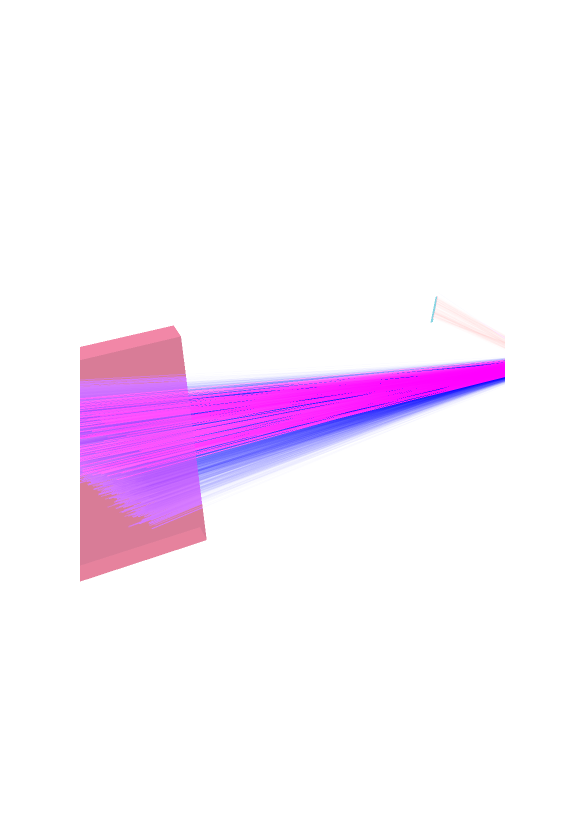

In [4]:
import xicsrt.visual.xicsrt_3d__plotly as xicsrt_3d

fig = xicsrt_3d.figure()
# xicsrt_3d.add_fluxsurfaces(result['config'], range_n=(0, np.pi*2))
xicsrt_3d.add_rays(result)
xicsrt_3d.add_optics(result['config'])
xicsrt_3d.add_sources(result['config'])

fig.update_layout(
    autosize=False,
    width=1000,
    height=800,
)

xicsrt_3d.show()

INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000400 num: 120
INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000400 num: 300


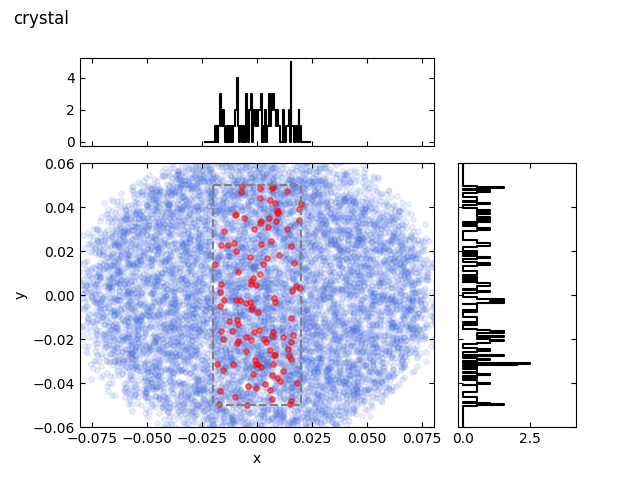

In [5]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_intersect(result, 'crystal', aspect='equal')

INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000172 num: 234
INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000172 num:1770


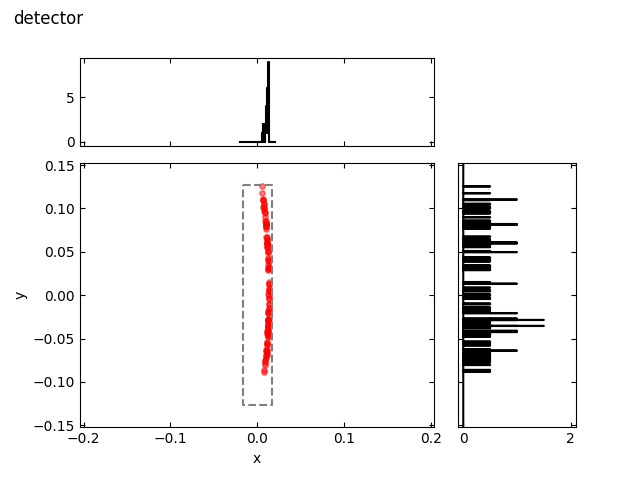

In [6]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_intersect(result, 'detector', aspect='equal')

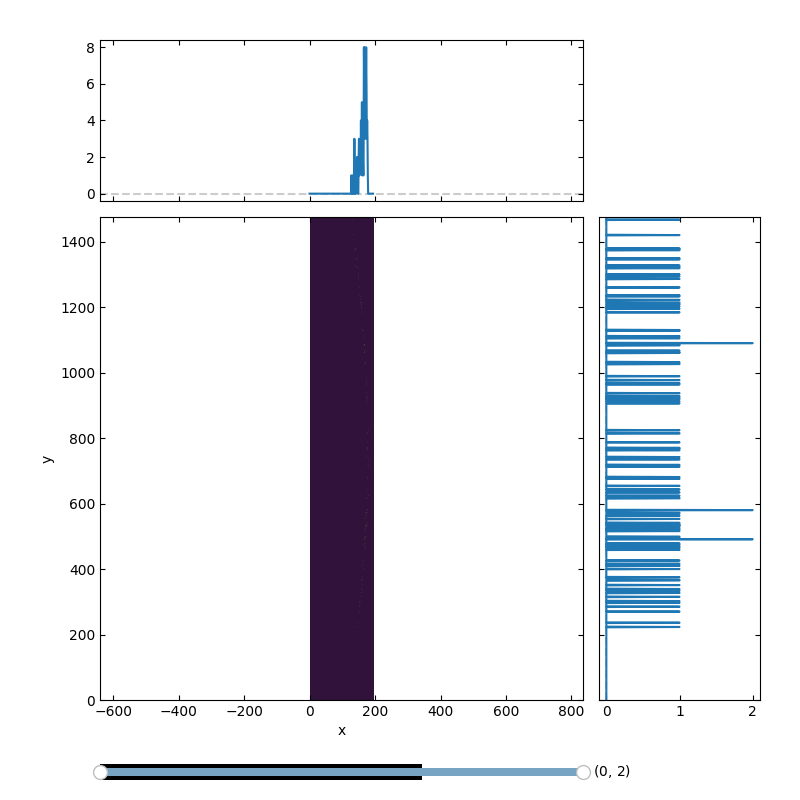

In [7]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_image(result, 'detector')